## Case Study D selection – KPI from AIOps 2018 dataset


The 2018 AIOps KPI anomaly detection dataset is used as the source for Case Study D.  
All candidate series are drawn from `Preliminary_dataset/train.csv` in the `KPI-Anomaly-Detection` repository.

Each row in `train.csv` has four columns:

- `timestamp`: Unix time in seconds
- `value`: KPI measurement at that time
- `label`: anomaly flag (0 = normal, 1 = anomalous)
- `KPI ID`: identifier for the KPI time series

Each unique `KPI ID` corresponds to one univariate KPI time series.


In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os


base_path = "../data/KPI-Anomaly-Detection-master/Preliminary_dataset/"

# Load one example file
file_path = os.path.join(base_path, "train.csv")
df = pd.read_csv(file_path)

df.head()
#KPI-Anomaly-Detection-master/Preliminary_dataset/train.csv

,timestamp,value,label,KPI ID
0,1493568000,1.901639,0,02e99bd4f6cfb33f
1,1493568060,1.786885,0,02e99bd4f6cfb33f
2,1493568120,2.000000,0,02e99bd4f6cfb33f
3,1493568180,1.885246,0,02e99bd4f6cfb33f
4,1493568240,1.819672,0,02e99bd4f6cfb33f


In [3]:
# Count how many anomalous points each KPI has
anomaly_counts_by_kpi = (
    df.groupby("KPI ID")["label"]
      .sum()
      .reset_index()
      .rename(columns={"label": "anomaly_point_count"})
      .sort_values("anomaly_point_count", ascending=False)
)

# Look at the top KPIs by anomaly count
anomaly_counts_by_kpi.head(10)


,KPI ID,anomaly_point_count
0,02e99bd4f6cfb33f,10550
5,1c35dbf57f55f5e4,9581
4,18fbb1d5a5dc099d,7863
24,da403e4e3f87c9e0,7666
12,88cf3a776ba00e7c,3106
15,8c892e5525f3e491,3083
25,e0770391decc44ce,3074
17,9ee5879409dccef9,2945
8,71595dd7171f4540,1113
23,cff6d3c01e6a6bfa,1087


### 1. Initial KPI screening using anomaly counts

To avoid selecting a trivial or extremely sparse series, anomaly statistics were first summarised for every `KPI ID` in `train.csv`.

For each KPI the following quantities were computed:

- `total_points`: number of time steps in the series  
- `anomaly_points`: number of time steps with `label = 1`  
- `anomaly_ratio`: `anomaly_points / total_points`

KPIs were then sorted by `anomaly_points`, and attention was restricted to those with:

- a long time series (around 120k–150k points), and  
- a mid-range `anomaly_ratio` (roughly 5–8%, i.e. clearly imbalanced but with enough anomalies to study).

This produced an initial shortlist of four candidate KPIs:

- `02e99bd4f6cfb33f`  
- `1c35dbf57f55f5e4`  
- `18fbb1d5a5dc099d`  
- `da403e4e3f87c9e0`


In [4]:
kpi_stats = (
    df.groupby("KPI ID")["label"]
      .agg(total_points="size", anomaly_points="sum")
      .reset_index()
)

kpi_stats["anomaly_ratio"] = (
    kpi_stats["anomaly_points"] / kpi_stats["total_points"]
)

# Inspect a few KPIs, sorted by anomaly_ratio or anomaly_points
kpi_stats.sort_values("anomaly_ratio", ascending=False).head(10)


,KPI ID,total_points,anomaly_points,anomaly_ratio
0,02e99bd4f6cfb33f,128562,10550,0.082062
5,1c35dbf57f55f5e4,128853,9581,0.074356
4,18fbb1d5a5dc099d,129128,7863,0.060893
24,da403e4e3f87c9e0,129035,7666,0.059410
12,88cf3a776ba00e7c,65436,3106,0.047466
17,9ee5879409dccef9,65449,2945,0.044997
15,8c892e5525f3e491,147009,3083,0.020972
25,e0770391decc44ce,147024,3074,0.020908
2,07927a9a18fa19ae,10960,130,0.011861
10,76f4550c43334374,8784,87,0.009904


### Value counts for each candidate

In [5]:
candidate_ids = [
    "02e99bd4f6cfb33f",
    "1c35dbf57f55f5e4",
    "18fbb1d5a5dc099d",
    "da403e4e3f87c9e0",
]

for kpi_id in candidate_ids:
    kpi_series = df[df["KPI ID"] == kpi_id].copy()
    kpi_series["time"] = pd.to_datetime(kpi_series["timestamp"], unit="s")

    print("KPI:", kpi_id)
    print(kpi_series["label"].value_counts(), "\n")


KPI: 02e99bd4f6cfb33f
label
0    118012
1     10550
Name: count, dtype: int64 

KPI: 1c35dbf57f55f5e4
label
0    119272
1      9581
Name: count, dtype: int64 

KPI: 18fbb1d5a5dc099d
label
0    121265
1      7863
Name: count, dtype: int64 

KPI: da403e4e3f87c9e0
label
0    121369
1      7666
Name: count, dtype: int64 



### 2. Visual inspection of anomaly patterns and baseline shape

Text(0.5, 1.0, '1c35dbf57f55f5e4')

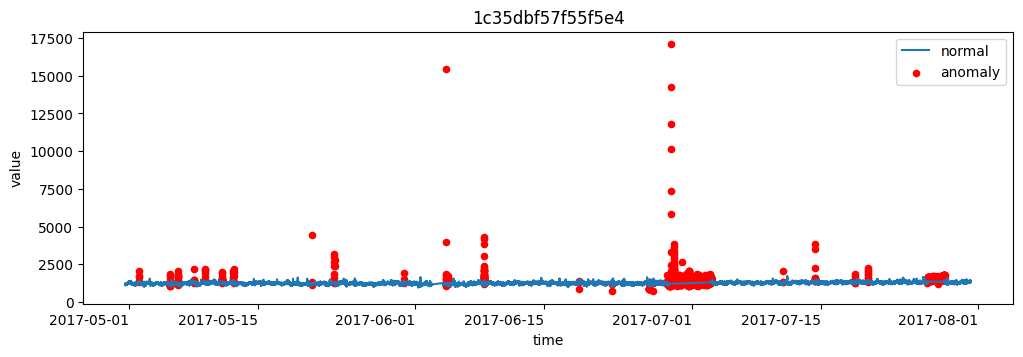

In [15]:
#DROPPED
chosen_kpi_id = "1c35dbf57f55f5e4"

kpi_series = df[df["KPI ID"] == chosen_kpi_id].copy()
kpi_series["time"] = pd.to_datetime(kpi_series["timestamp"], unit="s")

normal = kpi_series[kpi_series["label"] == 0]
anomalies = kpi_series[kpi_series["label"] == 1]

ax = normal.plot(x="time", y="value", figsize=(12, 4), label="normal")
anomalies.plot(
    x="time", y="value", kind="scatter", ax=ax, label="anomaly", color="red",
)
ax.set_title(chosen_kpi_id)



Text(0.5, 1.0, '18fbb1d5a5dc099d')

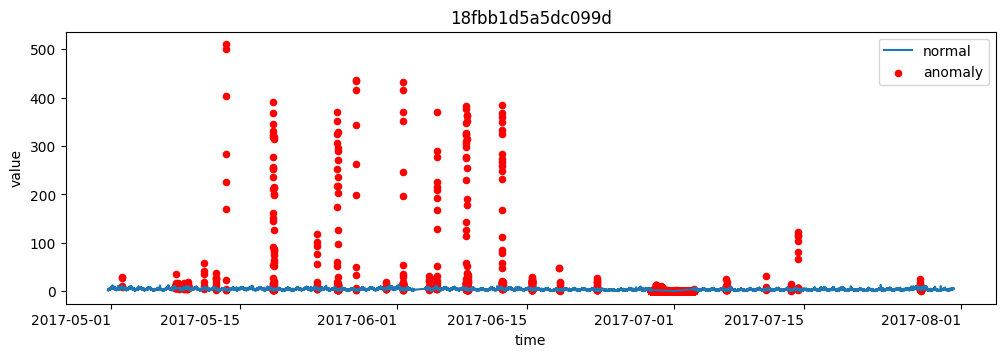

In [16]:
#DROPPED

chosen_kpi_id = "18fbb1d5a5dc099d"

kpi_series = df[df["KPI ID"] == chosen_kpi_id].copy()
kpi_series["time"] = pd.to_datetime(kpi_series["timestamp"], unit="s")

normal = kpi_series[kpi_series["label"] == 0]
anomalies = kpi_series[kpi_series["label"] == 1]

ax = normal.plot(x="time", y="value", figsize=(12, 4), label="normal")
anomalies.plot(
    x="time", y="value", kind="scatter", ax=ax, label="anomaly", color="red",
)
ax.set_title(chosen_kpi_id)


Text(0.5, 1.0, '02e99bd4f6cfb33f')

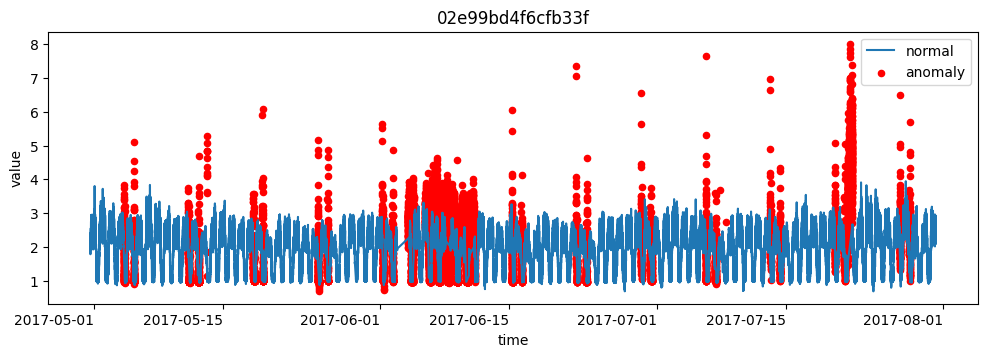

In [8]:
chosen_kpi_id = "02e99bd4f6cfb33f"

kpi_series = df[df["KPI ID"] == chosen_kpi_id].copy()
kpi_series["time"] = pd.to_datetime(kpi_series["timestamp"], unit="s")

normal = kpi_series[kpi_series["label"] == 0]
anomalies = kpi_series[kpi_series["label"] == 1]

ax = normal.plot(x="time", y="value", figsize=(12, 4), label="normal")
anomalies.plot(
    x="time", y="value", kind="scatter", ax=ax, label="anomaly", color="red",
)
ax.set_title(chosen_kpi_id)


Text(0.5, 1.0, 'da403e4e3f87c9e0')

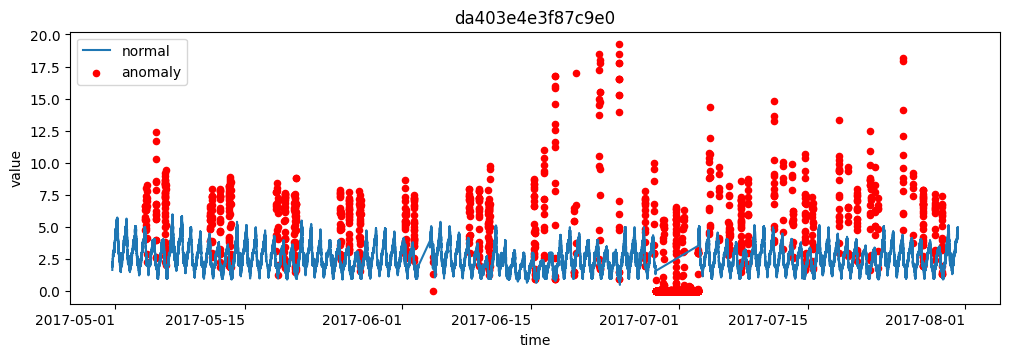

In [14]:
#chosen_kpi_id = ""  # try each of the four in turn

chosen_kpi_id = "da403e4e3f87c9e0"

kpi_series = df[df["KPI ID"] == chosen_kpi_id].copy()
kpi_series["time"] = pd.to_datetime(kpi_series["timestamp"], unit="s")

normal = kpi_series[kpi_series["label"] == 0]
anomalies = kpi_series[kpi_series["label"] == 1]

ax = normal.plot(x="time", y="value", figsize=(12, 4), label="normal")
anomalies.plot(
    x="time", y="value", kind="scatter", ax=ax, label="anomaly", color="red",
)
ax.set_title(chosen_kpi_id)


For each shortlisted KPI, the full time series was plotted with:

- blue points (`label = 0`) representing normal behaviour, and  
- red points (`label = 1`) representing anomalies.

The aim of this step was to understand:

- the shape of the normal baseline (flat versus periodic or business-like),  
- the arrangement of anomalies (isolated spikes, bursts, or long unstable periods), and  
- the presence of any obvious regime changes or instability.

Key observations:

- `1c35dbf57f55f5e4`: almost flat normal baseline with very large positive spikes as anomalies. This pattern is closer to a simple outlier-on-flat-line problem and is less informative for studying concept drift, so this KPI was discarded.
- `18fbb1d5a5dc099d`: mostly flat baseline with many spike anomalies concentrated in the earlier part of the series. This provides an “unstable → stable” pattern but with a relatively simple normal structure, and was therefore also discarded.
- `02e99bd4f6cfb33f`: clear daily rhythm with anomalies that include spikes and a dense unstable region in the middle of the series.
- `da403e4e3f87c9e0`: clear daily rhythm plus repeated anomaly bursts and a long unstable regime, containing both high spikes and low excursions.

After this step, `02e99bd4f6cfb33f` and `da403e4e3f87c9e0` were retained as the two main candidates.


# Analysis of remaining candidates

### 3. Early–middle–late anomaly behaviour

To capture changes in anomaly activity over time, each remaining KPI was split into three equal segments by index:

- early third  
- middle third  
- late third  

For each segment the anomaly ratio (fraction of points with `label = 1`) was computed.

Results:

- **KPI `02e99bd4f6cfb33f`**  
  - early: anomaly_ratio ≈ 3.6%  
  - middle: anomaly_ratio ≈ 17.0%  
  - late: anomaly_ratio ≈ 4.0%  

  This pattern is consistent with a mostly calm regime, a strongly unstable middle period, and a subsequent return to a calmer regime.

- **KPI `da403e4e3f87c9e0`**  
  - early: anomaly_ratio ≈ 0.9%  
  - middle: anomaly_ratio ≈ 10.2%  
  - late: anomaly_ratio ≈ 6.8%  

  This pattern indicates a very quiet early period, a clearly unstable middle period, and a late period that remains more anomalous than the start. The behaviour suggests a lasting change in regime rather than a single isolated incident.


In [17]:
import pandas as pd

# 1. Make sure we have a datetime column
df["time"] = pd.to_datetime(df["timestamp"], unit="s")

remaining_ids = ["02e99bd4f6cfb33f", "da403e4e3f87c9e0"]
summary_rows = []

for kpi_id in remaining_ids:
    kpi = df[df["KPI ID"] == kpi_id].sort_values("time").copy()
    n = len(kpi)

    # indices for early / middle / late thirds
    edges = [0, n // 3, 2 * n // 3, n]
    parts = ["early", "middle", "late"]

    for i in range(3):
        segment = kpi.iloc[edges[i]:edges[i+1]]
        anomaly_ratio = segment["label"].mean()  # mean of 0/1 = fraction anomalous

        summary_rows.append({
            "kpi_id": kpi_id,
            "segment": parts[i],
            "total_points": len(segment),
            "anomaly_ratio": anomaly_ratio
        })

summary = pd.DataFrame(summary_rows)
summary


,kpi_id,segment,total_points,anomaly_ratio
0,02e99bd4f6cfb33f,early,42854,0.035936
1,02e99bd4f6cfb33f,middle,42854,0.169949
2,02e99bd4f6cfb33f,late,42854,0.040300
3,da403e4e3f87c9e0,early,43011,0.008835
4,da403e4e3f87c9e0,middle,43012,0.101530
5,da403e4e3f87c9e0,late,43012,0.067865


KPI `da403e4e3f87c9e0` is selected as **Case Study D** for the following reasons:

1. **Business-like baseline behaviour**  
   The series exhibits a clear daily pattern in the normal data, consistent with an operational KPI driven by usage cycles.

2. **Rich anomaly structure**  
   Anomalies appear as a mix of isolated spikes, short bursts, and extended unstable periods, including both high-valued spikes and low excursions.

3. **Evidence of regime change and drift**  
   The anomaly ratio is very low in the early third, high in the middle third, and remains elevated in the late third. Together with the plots, this supports a narrative in which the system moves into, and partially remains in, a more unstable regime.

4. **Complementarity with other case studies**  
   Relative to the ambient temperature, NYC taxi demand, and NAB CPU series, this KPI contributes a new example of a service-level operational time series with many anomaly events, clear periodic structure, and non-trivial regime dynamics.

These properties make `da403e4e3f87c9e0` a suitable and well-justified choice for Case Study D in the overall evaluation of diffusion-based anomaly detection methods versus simple baselines.
